# Customer Segmentation Analysis

## Objective

The objective of this project is to segment customers based on their
purchasing behaviour using RFM analysis and K-Means clustering.

The three behavioural features used are Recency, Frequency, and Monetary.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [14]:
df = pd.read_csv("OnlineRetail.csv",encoding="latin1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [16]:
df.shape

(541909, 8)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [18]:
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custo

In [20]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [21]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [22]:
df = df.dropna(subset=["CustomerID"])

In [23]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [24]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [25]:
df["InvoiceDate"].dtype

dtype('<M8[us]')

In [26]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [27]:
df["InvoiceNo"].astype(str).str.startswith("C")

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Name: InvoiceNo, Length: 397924, dtype: bool

In [28]:
print("Negative quantities:", (df["Quantity"] <= 0).sum())
print("Invalid prices:", (df["UnitPrice"] <= 0).sum())

Negative quantities: 0
Invalid prices: 40


In [29]:
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [30]:
print("Rows after cleaning:", len(df))
print("Customers:", df["CustomerID"].nunique())
print("Duplicate rows:", df.duplicated().sum())
print("Missing Customer IDs:", df["CustomerID"].isnull().sum())

Rows after cleaning: 397884
Customers: 4338
Duplicate rows: 5192
Missing Customer IDs: 0


## 2. Data Cleaning

The dataset was cleaned before performing customer segmentation.

- Rows with missing CustomerID values were removed because CustomerID is
  required to identify individual customers.
- Duplicate records were removed to avoid double-counting transactions.
- InvoiceDate was converted to datetime format.
- Cancelled transactions were removed because they do not represent completed
  purchases.
- Transactions with non-positive quantities or prices were removed because
  they are not valid completed sales for RFM analysis.

The cleaned dataset is now ready for calculating RFM features.

## 3. Calculate Total Purchase Amount

The monetary value represents how much money each customer spends.

For each transaction, the total purchase amount is calculated by
multiplying the quantity purchased by the unit price.

In [31]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [32]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [33]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

In [34]:
rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalAmount": "Monetary"
}, inplace=True)

In [35]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [36]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [37]:
rfm.describe

<bound method NDFrame.describe of             Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40
...             ...        ...       ...
18280.0         278          1    180.60
18281.0         181          1     80.82
18282.0           8          2    178.05
18283.0           4         16   2094.88
18287.0          43          3   1837.28

[4338 rows x 3 columns]>

In [38]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [39]:
rfm.info()

<class 'pandas.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


In [42]:
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

In [43]:
rfm_features.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [44]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

In [46]:
rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.35866818],
       [-0.90534032,  0.3544168 ,  0.25096626],
       [-0.17535959, -0.03533985, -0.02859601],
       [-0.73534481, -0.4250965 , -0.0330118 ],
       [ 2.17457836, -0.4250965 , -0.19134727]])

In [47]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


In [48]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    
    inertia.append(kmeans.inertia_)

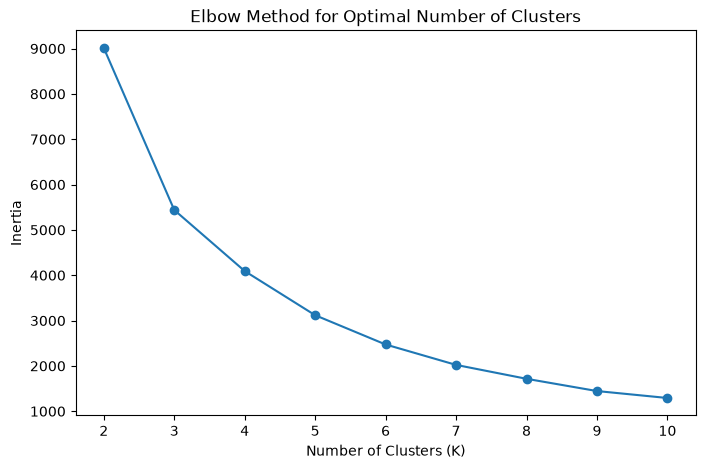

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [50]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

In [51]:
cluster_labels = kmeans.fit_predict(rfm_scaled)

In [52]:
rfm["Cluster"] = cluster_labels

In [54]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


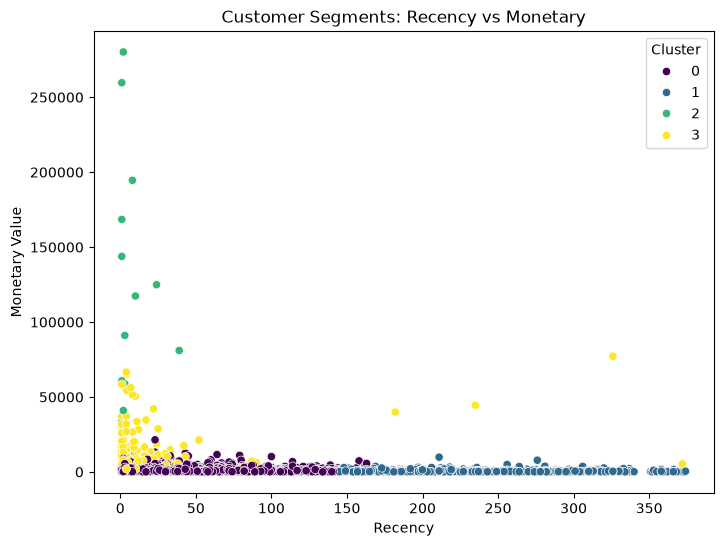

In [55]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")

plt.show()

In [56]:
cluster_profile = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1359.05
1,248.08,1.55,480.62
2,7.38,82.54,127338.31
3,15.50,22.33,12709.09


In [57]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

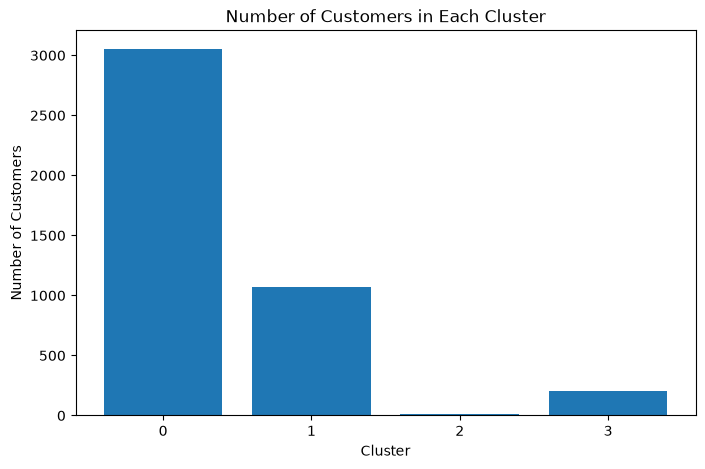

In [58]:
plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

## Cluster Profiling

The K-Means model identified four distinct customer segments based on
Recency, Frequency, and Monetary behaviour.

### Cluster 0 – Regular/Moderate Customers
This is the largest customer segment with 3,054 customers. Customers
have moderate recency, purchase frequency, and spending. Personalized
offers and loyalty incentives can be used to encourage more frequent
purchases.

### Cluster 1 – At-Risk/Inactive Customers
This segment contains 1,067 customers with high recency and low
frequency and monetary values. These customers appear less engaged.
Win-back campaigns, personalized discounts, and re-engagement
offers can be used to encourage repeat purchases.

### Cluster 2 – VIP/High-Value Customers
This is a very small segment of 13 customers with extremely low
recency, very high purchase frequency, and very high monetary value.
These customers represent the most valuable segment and should
receive VIP treatment, exclusive offers, and personalized services.

### Cluster 3 – Loyal High-Value Customers
This segment contains 204 customers who purchase frequently,
purchased recently, and have relatively high spending. Loyalty
programs, cross-selling, and personalized recommendations can help
increase their customer lifetime value.

## Insights and Marketing Recommendations

1. **Retain VIP customers:** Cluster 2 contains only 13 customers but
has extremely high frequency and monetary value. The company should
provide exclusive rewards, early access, and personalized services to
retain these high-value customers.

2. **Increase engagement among regular customers:** Cluster 0 is the
largest segment with 3,054 customers. Personalized recommendations,
bundled offers, and loyalty rewards can encourage these customers to
increase their purchase frequency and spending.

3. **Win back inactive customers:** Cluster 1 contains 1,067 customers
with an average recency of 248.08 days and low spending. The company
should run targeted re-engagement campaigns and limited-time offers
to bring these customers back.

4. **Grow loyal customers:** Cluster 3 contains 204 relatively high-value
customers. Cross-selling, upselling, and loyalty benefits can be used
to increase their spending and strengthen long-term relationships.